# Empirical Stylised Facts — ES 1-min Returns

Stylised-fact analysis of the **empirical** ES front-month 1-minute return
series, calm (2019) and stressed (COVID 2020-02-24 → 2020-04-02) regimes.
This is the data side — the moments the agent calibration (`calibrate.py`)
tries to match. Following HFABM Cao (2024) §4 and Cont (2001):

1. **Return distribution & heavy tails** — excess kurtosis.
2. **Hill tail index** — robust heavy-tail measure (HFABM uses it in place
   of kurtosis in the loss; kurtosis is dominated by a few outliers).
3. **ACF of returns** — Cont fact: ≈ 0 beyond microstructure lags
   (efficient-market signature).
4. **Volatility clustering** — ACF of |returns| and squared returns: slow,
   positive, long-memory decay.

The helper definitions (overnight-return drop, Hill estimator, 3-lag-smoothed
ACF) mirror `calibrate.py` exactly, so the numbers here equal the calibration
targets.


In [1]:
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from statistics import NormalDist

# Empirical 1-min series — same files calibrate.py reads (REGIME_DATA).
REGIME_DATA = {
    "calm":     "data/processed/ES_front_calm_1m.csv",
    "stressed": "data/processed/ES_front_stressed_1m.csv",
}
REGIMES = ("calm", "stressed")

# ACF lag battery — mirrors calibrate.py (D18e revised / D18g):
#   ACF1 (return ACF):   short lags {1,5,10} — the empirical return-ACF
#                        signal is at the short end; it is flat at 30/60/90.
#   ACF2 (|return| ACF): {1,10,30,60,90} — samples the slow clustering decay.
ACF1_LAGS   = (1, 5, 10)
ACF2_LAGS   = (1, 10, 30, 60, 90)
REPORT_LAGS = (1, 5, 10, 30, 60, 90)
MAX_LAG     = 120
HILL_FRAC   = 0.05      # top-fraction for the Hill estimator (Resnick 2007)


## Helpers

`load_returns` reproduces `calibrate.py`: 1-min log-returns of the mid,
with cross-day (overnight) returns dropped. `_acf_smoothed`, `hill_index`
mirror `calibrate.py` so the empirical numbers are the literal calibration
targets.


In [2]:
def load_returns(path):
    """1-min MID log-returns, overnight returns dropped (matches
    calibrate.py empirical_targets / data/v_gbm.py — all on the mid
    (best_bid+best_ask)/2, not the trade-price close)."""
    df = pd.read_csv(path, index_col=0, parse_dates=True)
    mid = df["mid"].to_numpy(dtype=float)
    logret = np.diff(np.log(mid))
    dates = pd.DatetimeIndex(df.index).date
    keep = dates[1:] == dates[:-1]              # drop the open-bar (overnight) return
    return logret[keep], int(len(set(dates)))


def acf(x, k):
    """Lag-k autocorrelation (mean-centered, calibrate.py._acf)."""
    if len(x) <= k:
        return np.nan
    x = x - x.mean()
    var = float((x * x).sum())
    return 0.0 if var == 0.0 else float((x[:-k] * x[k:]).sum() / var)


def acf_curve(x, max_lag=MAX_LAG):
    return np.array([acf(x, k) for k in range(1, max_lag + 1)])


def acf_smoothed(x, center):
    """Centred 3-lag average around `center` (Franke & Westerhoff 2012;
    calibrate.py._acf_smoothed) — lags {center-1, center, center+1}, or
    {1, 2} for center 1."""
    lags = (1, 2) if center <= 1 else (center - 1, center, center + 1)
    vals = [acf(x, l) for l in lags]
    vals = [v for v in vals if np.isfinite(v)]
    return float(np.mean(vals)) if vals else np.nan


def hill_index(returns, frac=HILL_FRAC):
    """Hill (1975) tail index on |returns| — P(|R|>x) ~ x^(-alpha).
    Larger alpha = lighter tail. Mirrors calibrate.py._hill_estimator."""
    a = np.abs(np.asarray(returns, dtype=float))
    a = a[np.isfinite(a) & (a > 0)]
    n = len(a)
    if n < 100:
        return np.nan
    k = max(int(frac * n), 20)
    if k >= n:
        return np.nan
    a_sorted = np.sort(a)[::-1]
    threshold = a_sorted[k]
    if threshold <= 0:
        return np.nan
    xi = float(np.mean(np.log(a_sorted[:k]) - np.log(threshold)))
    return 1.0 / xi if xi > 0 else np.nan


def hill_profile(returns, k_grid):
    """Hill index as a function of the number k of upper order statistics
    used — the standard stability diagnostic."""
    a = np.sort(np.abs(np.asarray(returns, dtype=float)))[::-1]
    a = a[a > 0]
    out = []
    for k in k_grid:
        if 2 <= k < len(a) and a[k] > 0:
            xi = float(np.mean(np.log(a[:k]) - np.log(a[k])))
            out.append(1.0 / xi if xi > 0 else np.nan)
        else:
            out.append(np.nan)
    return np.array(out)


def moments(r):
    """Cont-2001 + Hill battery of a 1-min log-return series."""
    z = (r - r.mean()) / r.std()
    return dict(
        n=len(r),
        mean=float(r.mean()), std=float(r.std()),
        skew=float((z ** 3).mean()),
        ex_kurtosis=float((z ** 4).mean() - 3.0),
        hill=hill_index(r),
        **{f"acf_r_{L}": acf_smoothed(r, L) for L in REPORT_LAGS},
        **{f"acf_absr_{L}": acf_smoothed(np.abs(r), L) for L in REPORT_LAGS},
        **{f"acf_sqr_{L}": acf_smoothed(r ** 2, L) for L in REPORT_LAGS},
    )


returns, n_days = {}, {}
for r in REGIMES:
    returns[r], n_days[r] = load_returns(REGIME_DATA[r])
    print(f"{r:9s}: {len(returns[r]):>7,d} RTH 1-min returns over {n_days[r]} days")


calm     : 102,501 RTH 1-min returns over 257 days
stressed :  11,416 RTH 1-min returns over 29 days


## 1 · Return distribution and heavy tails

Cont (2001) stylised fact: 1-min returns are **leptokurtic** — a sharp peak
and heavy tails relative to a Gaussian, so excess kurtosis ≫ 0. Kurtosis is
dominated by a handful of extreme observations, which is why HFABM reports
it for transparency but uses the Hill index (§2) in the calibration loss.


,calm,stressed
n returns,"102,501","11,416"
mean,1.21e-06,-6.36e-06
std,2.97e-04,1.82e-03
skew,-0.187,-0.964
excess kurtosis,19.9,34.8
Hill index,2.996,3.252


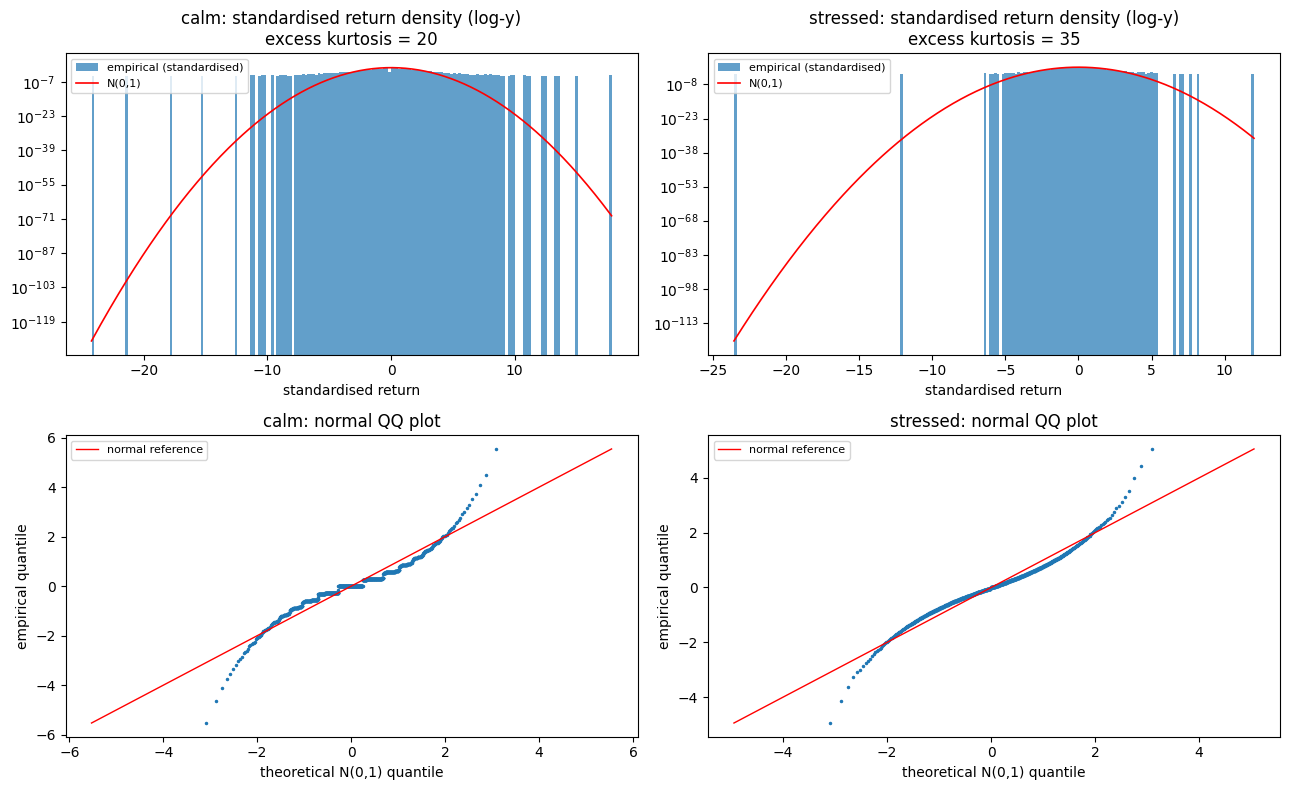

In [3]:
rows = {r: moments(returns[r]) for r in REGIMES}
summary = pd.DataFrame({
    r: {"n returns":       f"{rows[r]['n']:,}",
        "mean":            f"{rows[r]['mean']:.2e}",
        "std":             f"{rows[r]['std']:.2e}",
        "skew":            f"{rows[r]['skew']:.3f}",
        "excess kurtosis": f"{rows[r]['ex_kurtosis']:.1f}",
        "Hill index":      f"{rows[r]['hill']:.3f}"}
    for r in REGIMES})
display(summary)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for col, r in enumerate(REGIMES):
    x = returns[r]
    z = (x - x.mean()) / x.std()
    # Histogram vs fitted normal, log-y to expose the tails.
    ax = axes[0, col]
    ax.hist(z, bins=200, density=True, alpha=0.7, label="empirical (standardised)")
    grid = np.linspace(z.min(), z.max(), 400)
    ax.plot(grid, [NormalDist().pdf(g) for g in grid], "r-", lw=1.2, label="N(0,1)")
    ax.set_yscale("log")
    ax.set_title(f"{r}: standardised return density (log-y)\n"
                 f"excess kurtosis = {rows[r]['ex_kurtosis']:.0f}")
    ax.set_xlabel("standardised return"); ax.legend(fontsize=8)
    # Normal QQ plot — points bowing off the 45-deg line at the ends = heavy tails.
    ax = axes[1, col]
    qs = np.linspace(0.001, 0.999, 999)
    theo = np.array([NormalDist().inv_cdf(p) for p in qs])
    emp = np.quantile(z, qs)
    ax.plot(theo, emp, ".", ms=3)
    lim = [min(theo.min(), emp.min()), max(theo.max(), emp.max())]
    ax.plot(lim, lim, "r-", lw=1, label="normal reference")
    ax.set_title(f"{r}: normal QQ plot")
    ax.set_xlabel("theoretical N(0,1) quantile"); ax.set_ylabel("empirical quantile")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()


## 2 · Hill tail index

The Hill (1975) estimator fits a power law `P(|R| > x) ~ x^(-alpha)` to the
upper tail of `|returns|`. Smaller `alpha` = heavier tail; `alpha <= 2`
implies infinite variance, `alpha <= 4` infinite kurtosis. Empirical
equity-index returns typically sit around `alpha ≈ 3-4`.

The **Hill plot** shows the estimate as a function of `k`, the number of
upper order statistics used. A trustworthy estimate sits on a stable plateau;
the calibration target is the value at `k = 0.05 n` (vertical line).


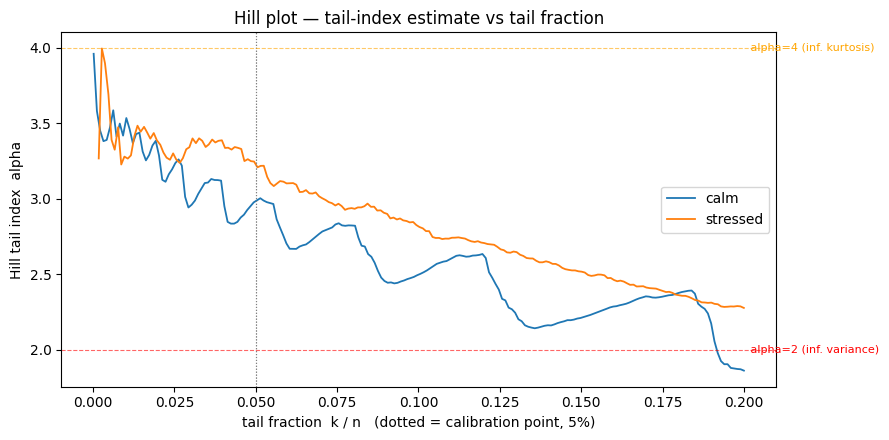

calm     : Hill index at 5% tail = 2.996
stressed : Hill index at 5% tail = 3.252


In [4]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for r in REGIMES:
    n = len(returns[r])
    k_grid = np.unique(np.linspace(20, int(0.20 * n), 200).astype(int))
    prof = hill_profile(returns[r], k_grid)
    ax.plot(k_grid / n, prof, lw=1.3, label=f"{r}")
    k_star = max(int(HILL_FRAC * n), 20)
    ax.axvline(k_star / n, color="grey", ls=":", lw=0.8)
ax.axhline(2, color="red", ls="--", lw=0.8, alpha=0.6)
ax.axhline(4, color="orange", ls="--", lw=0.8, alpha=0.6)
ax.text(0.201, 2, " alpha=2 (inf. variance)", color="red", fontsize=8, va="center")
ax.text(0.201, 4, " alpha=4 (inf. kurtosis)", color="orange", fontsize=8, va="center")
ax.set_xlabel(f"tail fraction  k / n   (dotted = calibration point, {HILL_FRAC:.0%})")
ax.set_ylabel("Hill tail index  alpha")
ax.set_title("Hill plot — tail-index estimate vs tail fraction")
ax.legend(); plt.tight_layout(); plt.show()

for r in REGIMES:
    print(f"{r:9s}: Hill index at {HILL_FRAC:.0%} tail = {hill_index(returns[r]):.3f}")


## 3 · Autocorrelation of returns

Cont (2001) stylised fact: raw returns show **no significant linear
autocorrelation** beyond the first few microstructure lags — the
efficient-market signature. The shaded band is the white-noise 95% interval
`±1.96/sqrt(n)`; bars inside it are statistically indistinguishable from
zero. HFABM lags {30, 60, 90} are marked.


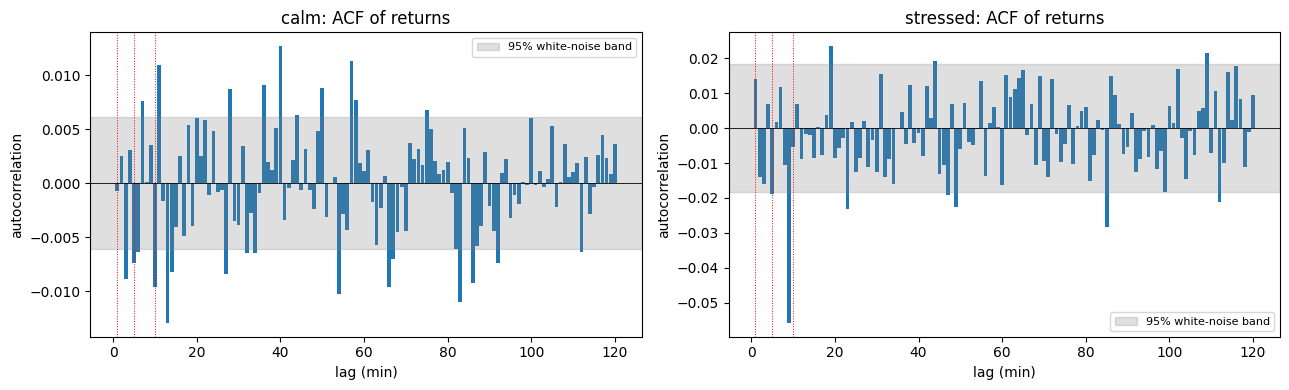

   lag          calm      stressed
     1        0.0009        0.0000
     5       -0.0035       -0.0034
    10        0.0016       -0.0180
    30       -0.0013       -0.0001
    60        0.0020       -0.0002
    90       -0.0012       -0.0029


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, r in zip(axes, REGIMES):
    curve = acf_curve(returns[r])
    band = 1.96 / np.sqrt(len(returns[r]))
    lags = np.arange(1, MAX_LAG + 1)
    ax.bar(lags, curve, width=0.9)
    ax.axhspan(-band, band, color="grey", alpha=0.25, label="95% white-noise band")
    for L in ACF1_LAGS:
        ax.axvline(L, color="red", ls=":", lw=0.7)
    ax.axhline(0, color="k", lw=0.6)
    ax.set_title(f"{r}: ACF of returns")
    ax.set_xlabel("lag (min)"); ax.set_ylabel("autocorrelation"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"{'lag':>6}" + "".join(f"{r:>14}" for r in REGIMES))
for L in REPORT_LAGS:
    vals = "".join(f"{acf_smoothed(returns[r], L):>14.4f}" for r in REGIMES)
    print(f"{L:>6}{vals}")


## 4 · Volatility clustering — ACF of |returns| and squared returns

Cont (2001) stylised fact: while raw returns are uncorrelated, **non-linear
functions of returns — |r| and r² — show slow, positive, long-memory
autocorrelation**. Large moves cluster with large moves. Both `|r|` and `r²`
are standard clustering proxies; `|r|` is the more robust (less
outlier-sensitive) and is what `calibrate.py` uses (`acf_absr`).

Compare the decay here against the flat ACF in §3 — that contrast *is* the
volatility-clustering stylised fact.


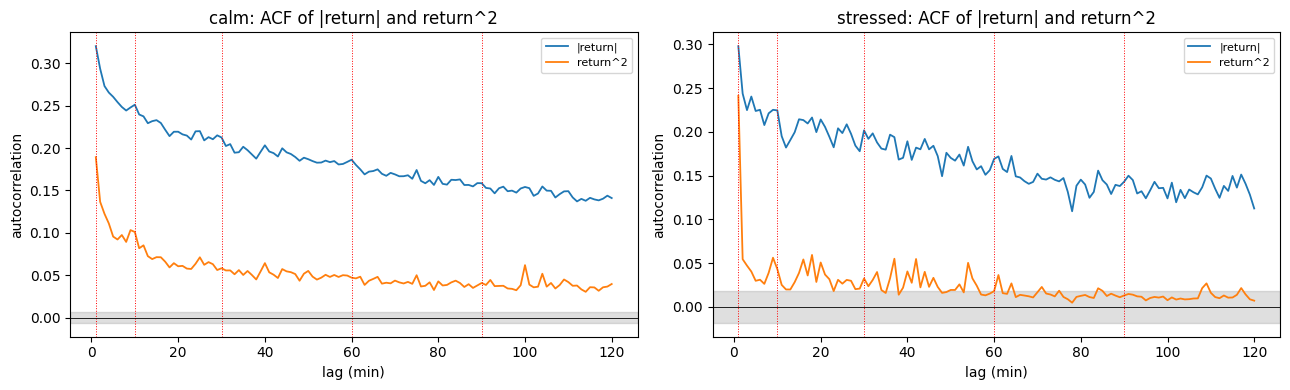

   lag      calm |r|      calm r^2  stressed |r|  stressed r^2
     1        0.3068        0.1629        0.2708        0.1478
     5        0.2600        0.0996        0.2298        0.0337
    10        0.2461        0.0954        0.2149        0.0415
    30        0.2099        0.0567        0.1905        0.0256
    60        0.1833        0.0477        0.1657        0.0231
    90        0.1567        0.0392        0.1437        0.0129


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, r in zip(axes, REGIMES):
    x = returns[r]
    band = 1.96 / np.sqrt(len(x))
    lags = np.arange(1, MAX_LAG + 1)
    ax.plot(lags, acf_curve(np.abs(x)), lw=1.3, label="|return|")
    ax.plot(lags, acf_curve(x ** 2),  lw=1.3, label="return^2")
    ax.axhspan(-band, band, color="grey", alpha=0.25)
    for L in ACF2_LAGS:
        ax.axvline(L, color="red", ls=":", lw=0.7)
    ax.axhline(0, color="k", lw=0.6)
    ax.set_title(f"{r}: ACF of |return| and return^2")
    ax.set_xlabel("lag (min)"); ax.set_ylabel("autocorrelation"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"{'lag':>6}" + "".join(f"{r+' |r|':>14}{r+' r^2':>14}" for r in REGIMES))
for L in REPORT_LAGS:
    cells_ = ""
    for r in REGIMES:
        cells_ += f"{acf_smoothed(np.abs(returns[r]), L):>14.4f}"
        cells_ += f"{acf_smoothed(returns[r] ** 2, L):>14.4f}"
    print(f"{L:>6}{cells_}")


## 5 · Empirical moment targets (calibration reference)

The consolidated battery — these are the literal targets `calibrate.py`
matches. `ret_std`, the return-ACF, the |return|-ACF and the Hill index feed
the loss (the loss groups them as ΔV, ΔACF1, ΔACF2, ΔHill — D18g). `ex_kurtosis` is reported for transparency but is
**not** in the loss (HFABM convention — Hill is the robust tail measure).


In [7]:
# Consolidated moment battery — mirrors calibrate.py MOMENT_NAMES (D18g).
# These are the literal calibration targets (computed on the mid, centred
# 3-lag smoothing). ex_kurtosis is diagnostic only — not a loss moment.
table = {}
for r in REGIMES:
    x = returns[r]
    z = (x - x.mean()) / x.std()
    col = {"ret_std": float(x.std()),
           "ex_kurtosis": float((z ** 4).mean() - 3.0),
           "hill_tail_index": hill_index(x)}
    for L in ACF1_LAGS:
        col[f"acf_r_{L}"] = acf_smoothed(x, L)
    for L in ACF2_LAGS:
        col[f"acf_absr_{L}"] = acf_smoothed(np.abs(x), L)
    table[r] = col

order = (["ret_std", "ex_kurtosis", "hill_tail_index"]
         + [f"acf_r_{L}" for L in ACF1_LAGS]
         + [f"acf_absr_{L}" for L in ACF2_LAGS])
tbl = pd.DataFrame(table).reindex(order)
display(tbl.round(6))


,calm,stressed
ret_std,0.000297,0.001823
ex_kurtosis,19.865568,34.754911
hill_tail_index,2.996027,3.252366
acf_r_1,0.000917,0.000044
acf_r_5,-0.003539,-0.003365
acf_r_10,0.001608,-0.018042
acf_absr_1,0.306776,0.270845
acf_absr_10,0.246126,0.214945
acf_absr_30,0.209923,0.190534
acf_absr_60,0.183321,0.165730


## Notes

- **Heavy tails — present.** Excess kurtosis is large in both regimes and the
  QQ plots bow sharply off the normal line at the extremes. The Hill index
  quantifies it robustly; read the calibration target off the plateau of the
  Hill plot.
- **Return ACF — flat.** Raw-return autocorrelation sits inside the
  white-noise band beyond the first lag or two — the efficient-market
  signature the simulated market should also reproduce.
- **Volatility clustering — present in the data.** `|r|` and `r²` show the
  slow positive decay. This is the stylised fact the FT+MT+MM+ZI model does
  **not** reproduce (no agent carries a persistent volatility state) — which
  is why ΔACF2 is kept in the calibration loss as a structural-gap
  benchmark (D18g) — the gap a future clustering mechanism must close.
- These empirical numbers equal `calibrate.py`'s targets by construction
  (same overnight-drop, same Hill estimator, same 3-lag-smoothed ACF).
